## EDA for Business Class Flight Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("business_cleaned.csv", parse_dates=["date"])

In [3]:
df.sample(10)

,date,airline,ch_code,flight_number,from,to,via_city,route,stop_count,arr_hour,arr_period,dep_hour,dep_period,duration_mins,days_left,price
73116,2022-03-23,Air India,AI,840,Hyderabad,Mumbai,NaN,Hyderabad-Mumbai,1,12,Afternoon,20,Night,960,41,45883
10877,2022-03-08,Vistara,UK,879,Delhi,Kolkata,NaN,Delhi-Kolkata,2,9,Morning,17,Evening,960,26,72339
29431,2022-03-08,Vistara,UK,986,Mumbai,Kolkata,NaN,Mumbai-Kolkata,1,8,Morning,22,Night,590,26,49725
83656,2022-03-31,Vistara,UK,822,Chennai,Delhi,NaN,Chennai-Delhi,1,16,Afternoon,9,Morning,430,49,57920
527,2022-02-16,Vistara,UK,813,Delhi,Mumbai,NaN,Delhi-Mumbai,1,23,Night,17,Evening,350,6,60601
52175,2022-03-29,Vistara,UK,818,Bangalore,Hyderabad,NaN,Bangalore-Hyderabad,1,9,Morning,19,Evening,825,47,56588
82544,2022-03-12,Air India,AI,539,Chennai,Delhi,NaN,Chennai-Delhi,0,19,Evening,17,Evening,170,30,27792
75008,2022-03-09,Vistara,UK,878,Hyderabad,Bangalore,NaN,Hyderabad-Bangalore,1,20,Night,12,Afternoon,480,27,38099
16071,2022-02-25,Vistara,UK,933,Delhi,Chennai,NaN,Delhi-Chennai,1,23,Night,15,Afternoon,455,15,57992
25851,2022-03-12,Vistara,UK,970,Mumbai,Bangalore,NaN,Mumbai-Bangalore,1,23,Night,8,Morning,875,30,69168


In [4]:
print("First_date:", df['date'].min())
print("\nLast_date:", df['date'].max())
print("\nduration:", (df['date'].max() - df['date'].min()))

First_date: 2022-02-11 00:00:00

Last_date: 2022-03-31 00:00:00

duration: 48 days 00:00:00


## **Univariate Analysis**

count     93487.000000
mean      52540.081124
std       12969.314606
min       12000.000000
25%       45185.000000
50%       53164.000000
75%       60396.000000
max      123071.000000
Name: price, dtype: float64


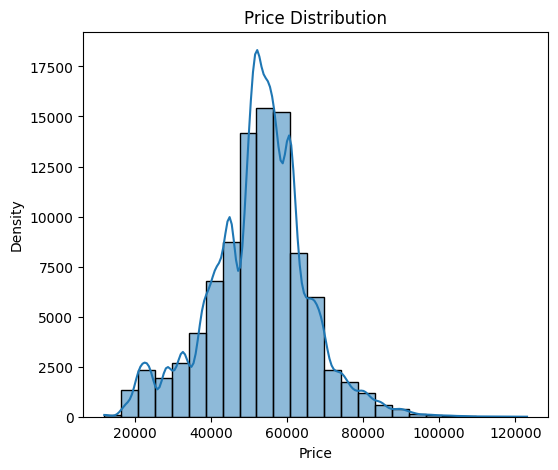

In [5]:
print(df['price'].describe())

plt.figure(figsize= (6,5))
sns.histplot(df['price'], bins= 25, edgecolor= 'black', kde= True)
plt.xlabel('Price')
plt.ylabel('Density')
plt.title('Price Distribution')
plt.show()

## Airline
**only two airlines --> `Vistara`(64.81%) & `Air India`(35.19)**

airline
Vistara      64.810081
Air India    35.189919
Name: count, dtype: float64


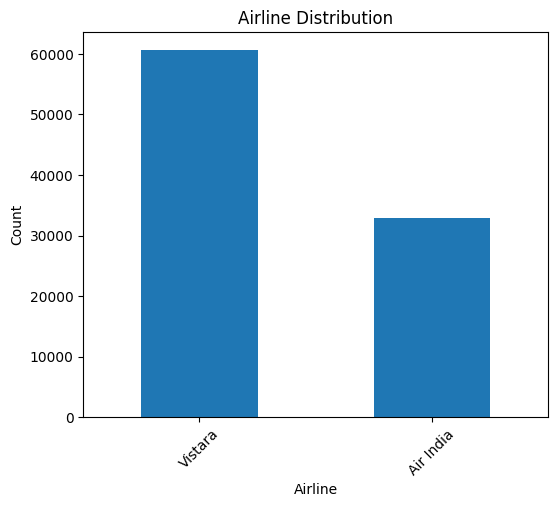

In [6]:
print(df['airline'].value_counts()*100/len(df))

fig = plt.figure(figsize= (6,5))
df['airline'].value_counts().plot(kind= 'bar')
plt.xlabel('Airline')
plt.ylabel('Count')
plt.title('Airline Distribution')
plt.xticks(rotation= 45)
plt.show()

## `Flight_number`
**flight_number won't be useful for predictions and model..**

**Even if some tickets of specific flight_numbers are costlies and some are cheaper but we aready have the other columns exactly for analysing why some flights have high priced tickets and some has cheaper**

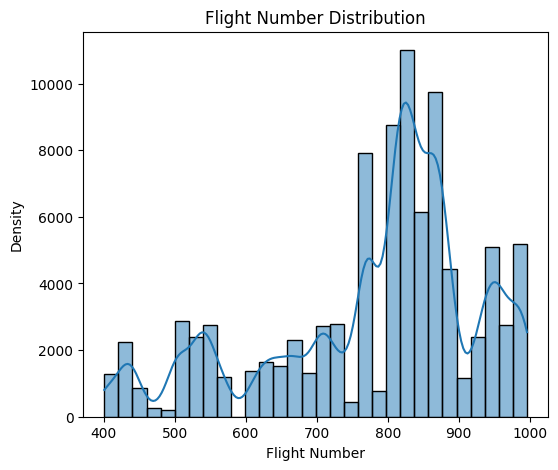

In [7]:
plt.figure(figsize=(6,5))
sns.histplot(df['flight_number'], bins=30, kde=True)
plt.xlabel('Flight Number')
plt.ylabel('Density')
plt.title('Flight Number Distribution')
plt.show()

## `Route`
**This dataset is well distributed in all routes**
**among them, Delhi-Mumbai route is most frequent with 5.68% and Chennai-Hyderabad is least frequent with 2.24%**

route
Delhi-Mumbai           5.676725
Mumbai-Delhi           5.356895
Bangalore-Mumbai       4.488325
Mumbai-Bangalore       4.470140
Delhi-Bangalore        4.137474
Mumbai-Kolkata         4.094687
Bangalore-Delhi        4.061527
Mumbai-Hyderabad       3.722443
Kolkata-Mumbai         3.598361
Mumbai-Chennai         3.597292
Delhi-Kolkata          3.508509
Bangalore-Kolkata      3.359825
Delhi-Chennai          3.330944
Hyderabad-Mumbai       3.287088
Chennai-Mumbai         3.263555
Bangalore-Hyderabad    3.223978
Kolkata-Bangalore      3.134126
Delhi-Hyderabad        2.938376
Chennai-Delhi          2.912704
Kolkata-Delhi          2.877405
Hyderabad-Bangalore    2.877405
Chennai-Bangalore      2.707328
Hyderabad-Delhi        2.662402
Hyderabad-Kolkata      2.542600
Kolkata-Hyderabad      2.505161
Bangalore-Chennai      2.452747
Hyderabad-Chennai      2.397125
Kolkata-Chennai        2.296576
Chennai-Kolkata        2.280531
Chennai-Hyderabad      2.237744
Name: count, dtype: float64


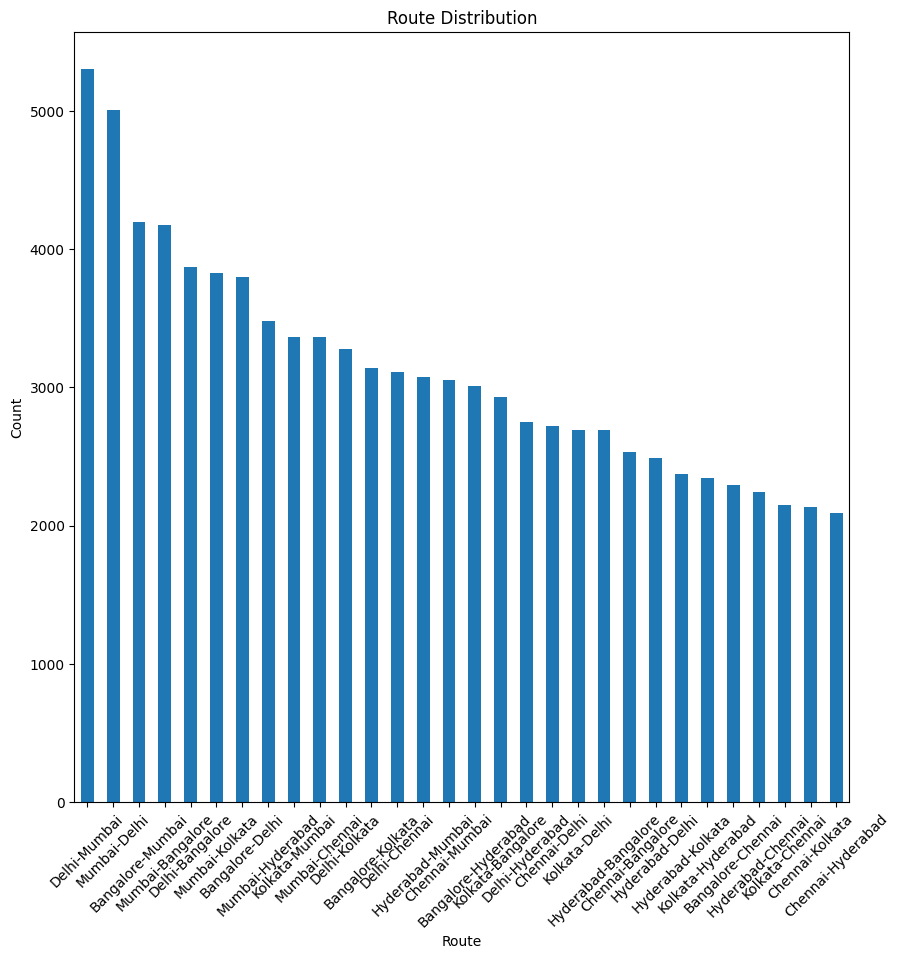

In [8]:
print(df['route'].value_counts()*100/len(df))

plt.figure(figsize=(10,10))
df['route'].value_counts().plot(kind='bar')
plt.xlabel('Route')
plt.ylabel('Count')
plt.title('Route Distribution')
plt.xticks(rotation= 45)
plt.show()

## `Stop Count`
**This is really interesting is that about `90.17%` of flights has `1-stoppage` in-between**

**`0-stoppage` is `8.67%` and `2-stoppage` in-between flights are only `1.16%`**

stop_count
1    90.175105
0     8.666446
2     1.158450
Name: count, dtype: float64


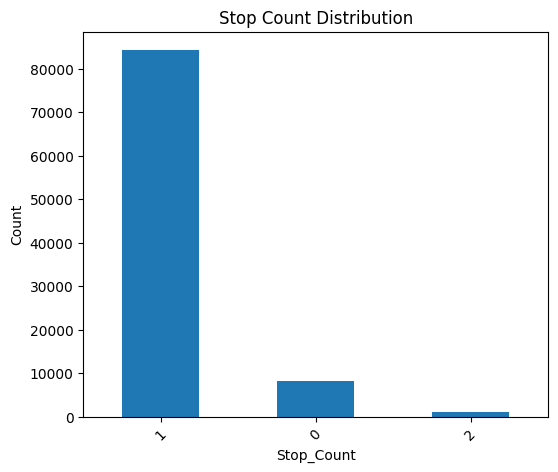

In [9]:
print(df['stop_count'].value_counts()*100/len(df))

plt.figure(figsize=(6,5))
df['stop_count'].value_counts().plot(kind='bar')
plt.xlabel('Stop_Count')
plt.ylabel('Count')
plt.title('Stop Count Distribution')
plt.xticks(rotation= 45)
plt.show()

## Arrival hour
**Overall median is 17 hours for arrival time**

**While also the median for both airlines are same as 17 hour**

count    93487.000000
mean        15.687454
std          5.604107
min          0.000000
25%         11.000000
50%         17.000000
75%         20.000000
max         23.000000
Name: arr_hour, dtype: float64


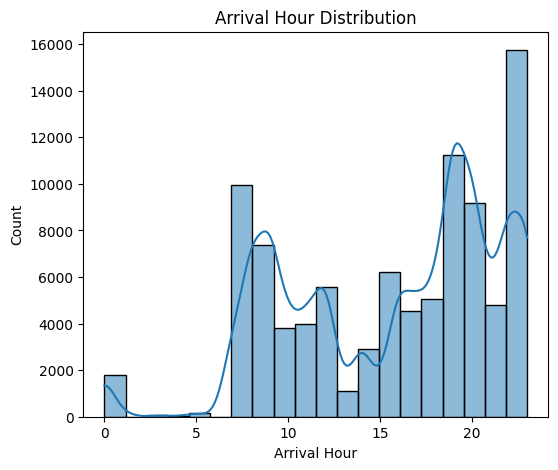

In [10]:
print(df['arr_hour'].describe())

plt.figure(figsize=(6,5))
sns.histplot(df['arr_hour'], bins= 20, kde= True, edgecolor= 'black')
plt.xlabel('Arrival Hour')
plt.ylabel('Count')
plt.title('Arrival Hour Distribution')
plt.show()

## Departure hour
**Overall median is 13 hours**

**In departure `Vistara` takes 1 hour less than `Air India` for departure**

count    93487.000000
mean        13.290939
std          5.358745
min          2.000000
25%          8.000000
50%         13.000000
75%         19.000000
max         23.000000
Name: dep_hour, dtype: float64
             count       mean       std  min  25%   50%   75%   max
airline                                                            
Air India  32898.0  13.243054  5.478392  2.0  8.0  13.0  19.0  23.0
Vistara    60589.0  13.316939  5.292511  5.0  8.0  12.0  19.0  22.0


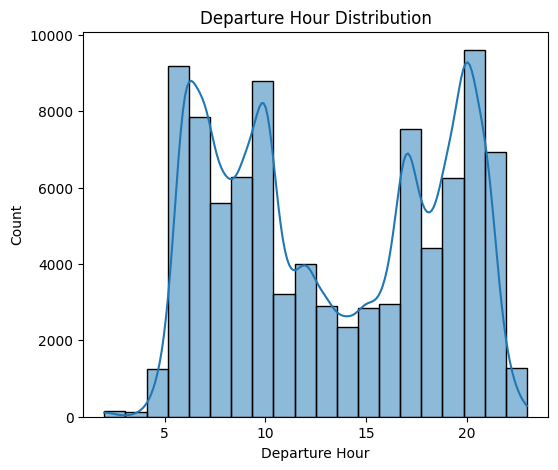

In [11]:
print(df['dep_hour'].describe())

print(df.groupby('airline')['dep_hour'].describe())

plt.figure(figsize=(6,5))
sns.histplot(df['dep_hour'], bins= 20, kde= True, edgecolor= 'black')
plt.xlabel('Departure Hour')
plt.ylabel('Count')
plt.title('Departure Hour Distribution')
plt.show()

## Arrival Period
**31.82% flights arrives at night (8-11.59)pm**

**Only 2.12% flights arrives in `Late_Night`(12-6)am**

arr_period
Night         31.824746
Morning       26.888230
Evening       22.267267
Afternoon     16.886840
Late_Night     2.132917
Name: count, dtype: float64


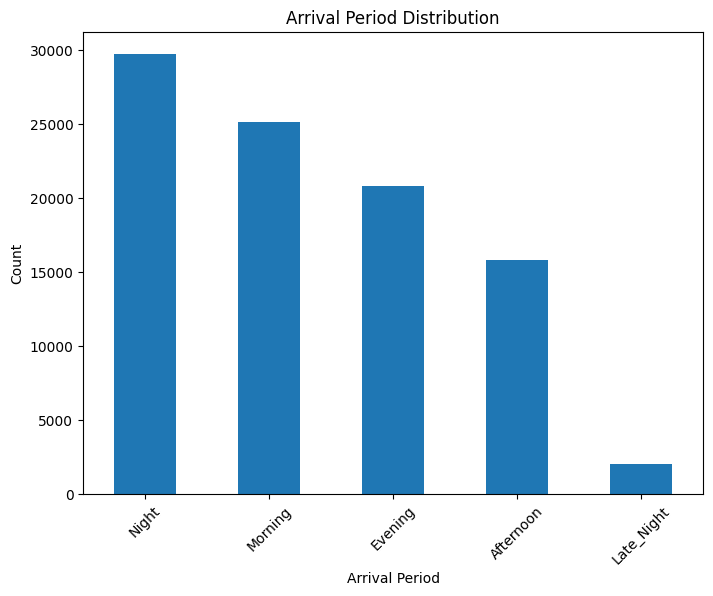

In [12]:
print(df['arr_period'].value_counts()*100/len(df))

plt.figure(figsize=(8,6))
df['arr_period'].value_counts().plot(kind= 'bar')
plt.xlabel('Arrival Period')
plt.ylabel('Count')
plt.title('Arrival Period Distribution')
plt.xticks(rotation=45)
plt.show()

## Departure period
**`43.74%` flights `Morning` mein depart karti hain — sabse zyada.**

**`Late_Night` sabse kam hai (`1.62%`) — arrival period ke `Late_Night` (`2.12%`) se bhi kam.**

dep_period
Morning       43.742980
Evening       19.507525
Night         19.046498
Afternoon     16.080311
Late_Night     1.622686
Name: count, dtype: float64


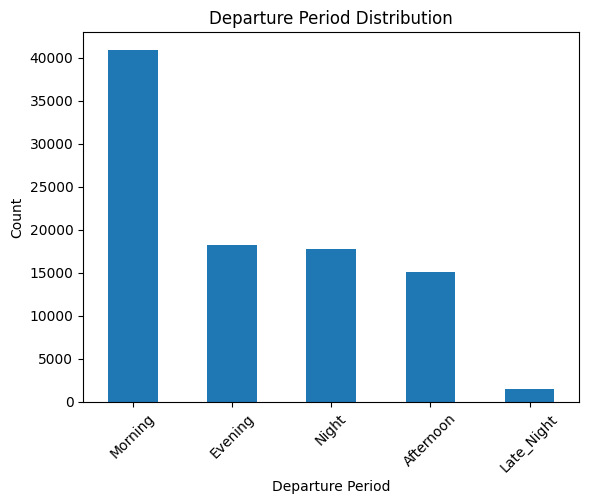

In [13]:
print(df['dep_period'].value_counts()*100/len(df))

df['dep_period'].value_counts().plot(kind='bar')
plt.xlabel('Departure Period')
plt.ylabel('Count')
plt.title('Departure Period Distribution')
plt.xticks(rotation=45)
plt.show()

## Duration_minutes
**Median duration is `785 minutes (13 hrs 25 mins)` and skewness is 0.27**

**Duration mins does mean time of flying it consists of layover time as well therefore the outliers are valid**

count    93487.000000
mean       822.253468
std        411.148768
min         60.000000
25%        530.000000
50%        785.000000
75%       1070.000000
max       2865.000000
Name: duration_mins, dtype: float64


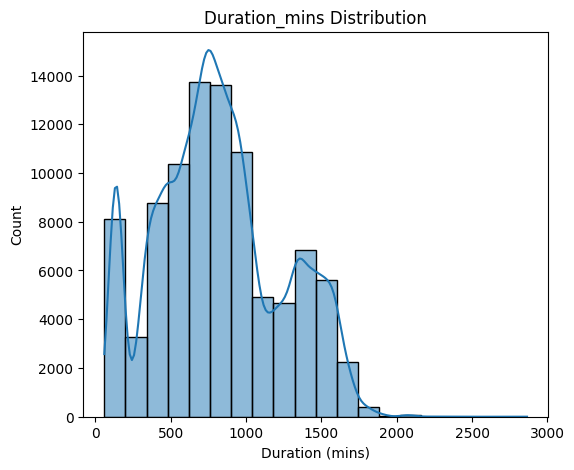

0.27323782894746435


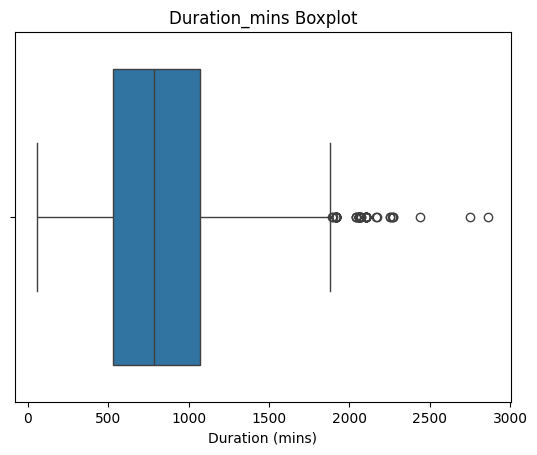

,date,airline,ch_code,flight_number,from,to,via_city,route,stop_count,arr_hour,arr_period,dep_hour,dep_period,duration_mins,days_left,price
27721,2022-02-15,Vistara,UK,653,Mumbai,Kolkata,NaN,Mumbai-Kolkata,1,19,Evening,6,Morning,2255,5,58708
27818,2022-02-16,Vistara,UK,653,Mumbai,Kolkata,NaN,Mumbai-Kolkata,1,18,Evening,6,Morning,2165,6,72338
27819,2022-02-16,Vistara,UK,653,Mumbai,Kolkata,NaN,Mumbai-Kolkata,1,19,Evening,6,Morning,2255,6,72338
45722,2022-03-26,Air India,AI,573,Bangalore,Mumbai,Patna,Bangalore-Mumbai,1,20,Night,12,Afternoon,1900,44,56058
52354,2022-02-12,Air India,AI,507,Bangalore,Chennai,NaN,Bangalore-Chennai,2,23,Night,6,Morning,2440,2,65674
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87105,2022-02-19,Air India,AI,569,Chennai,Bangalore,NaN,Chennai-Bangalore,1,14,Afternoon,6,Morning,1920,9,52139
87489,2022-02-26,Air India,AI,569,Chennai,Bangalore,NaN,Chennai-Bangalore,1,14,Afternoon,6,Morning,1920,16,52139
89074,2022-03-28,Air India,AI,509,Chennai,Bangalore,NaN,Chennai-Bangalore,2,18,Evening,8,Morning,2070,46,54986
89286,2022-02-12,Vistara,UK,836,Chennai,Kolkata,NaN,Chennai-Kolkata,1,20,Night,10,Morning,2040,2,68963


In [14]:
print(df['duration_mins'].describe())

plt.figure(figsize=(6,5))
sns.histplot(df['duration_mins'], bins= 20, kde= True, edgecolor= 'black')
plt.xlabel('Duration (mins)')
plt.ylabel('Count')
plt.title('Duration_mins Distribution')
plt.show()

print(df['duration_mins'].skew())

sns.boxplot(df['duration_mins'], orient='h')
plt.xlabel('Duration (mins)')
plt.title('Duration_mins Boxplot')
plt.show()

# Outliers overview
Q3 = df['duration_mins'].quantile(0.75)
Q1 = df['duration_mins'].quantile(0.25)

IQR = Q3-Q1
upper_bound = 1.5*IQR + Q3

df[df['duration_mins'] > upper_bound]

## Days_left
**Median days_left is 26 days and skewness is 0.01 with no outliers.**

count    93487.000000
mean        25.741857
std         13.626538
min          1.000000
25%         14.000000
50%         26.000000
75%         38.000000
max         49.000000
Name: days_left, dtype: float64


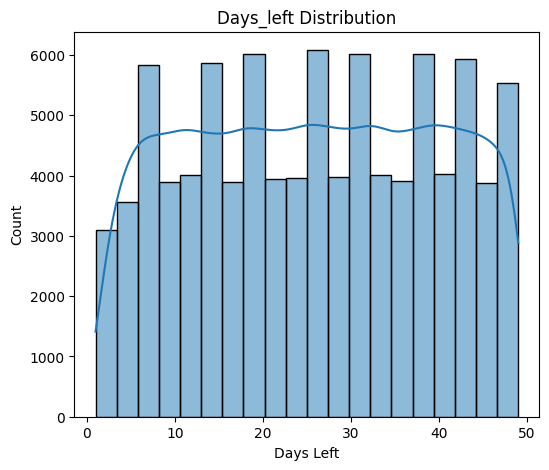

-0.011765171668831762


In [15]:
print(df['days_left'].describe())

plt.figure(figsize=(6,5))
sns.histplot(df['days_left'], bins= 20, kde= True, edgecolor= 'black')
plt.xlabel('Days Left')
plt.ylabel('Count')
plt.title('Days_left Distribution')
plt.show()

print(df['days_left'].skew())

## Bivariate Analysis

## Airline vs Price
**median of `Vistara` is more than `Air India`**

**maximum ticktet price in business class of `Vistara` is high priced than of `Air India`**

**`Vistara` tickets are most expensive than `Air India` and this is not explained by duration and stoppage**

**`26/30` routes of `Vistara` are costlier than `Air India` and it explains why `Vistara` is high priced than `Air India`**

             count          mean           std      min      25%      50%  \
airline                                                                     
Air India  32898.0  47131.039212  10521.926556  12000.0  42457.0  49613.0   
Vistara    60589.0  55477.027777  13225.349062  17604.0  49207.0  56588.0   

               75%       max  
airline                       
Air India  54608.0   90970.0  
Vistara    62591.0  123071.0  


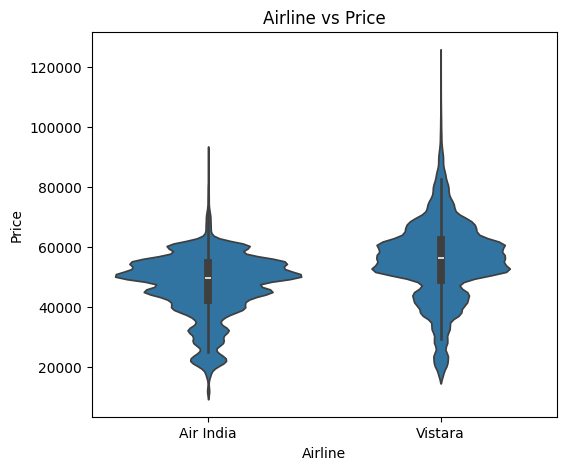

           duration_mins  stop_count
airline                             
Air India     878.090309    0.912761
Vistara       791.935747    0.931522


airline    from       to       
Air India  Bangalore  Chennai      56301.932367
                      Delhi        40608.953832
                      Hyderabad    51169.902655
                      Kolkata      55836.149203
                      Mumbai       51648.610770
           Chennai    Bangalore    56733.854749
                      Delhi        42005.112344
                      Hyderabad    50870.054264
                      Kolkata      54365.963357
                      Mumbai       48780.453267
           Delhi      Bangalore    41222.324257
                      Chennai      43908.948762
                      Hyderabad    39139.171113
                      Kolkata      45732.957367
                      Mumbai       41907.872651
           Hyderabad  Bangalore    51507.926184
                      Chennai      49649.855110
                      Delhi        39074.973877
                      Kolkata      48849.182984
                      Mumbai       44073.868324
        

In [16]:
print(df.groupby('airline')['price'].describe())

plt.figure(figsize=(6,5))
sns.violinplot(data = df, x= 'airline', y='price')
plt.xlabel('Airline')
plt.ylabel('Price')
plt.title('Airline vs Price')
plt.show()

print(df.groupby(['airline'])[['duration_mins','stop_count']].mean())

df.groupby(['airline', 'from', 'to'])['price'].mean()

## Departure_city
**Kolkata shows the highest overall median departure price, but this isn't because Kolkata is genuinely the most expensive city to fly from — it doesn't lead any individual stop-count segment (Bangalore leads non-stop and 1-stop; Delhi leads 2-stop). The real driver is route composition: Kolkata has one of the lowest shares of non-stop flights (5.46%) of any city, meaning very few cheap direct-flight prices exist to pull its aggregate median down. Delhi, with the highest non-stop share (15.49%, nearly 3x Kolkata's), has a much larger volume of cheap flights dragging its overall median to the lowest of all six cities**

             count          mean           std      min      25%      50%  \
from                                                                        
Bangalore  16441.0  53723.539687  12249.652344  12000.0  44280.0  54841.0   
Chennai    12529.0  54140.530529  12041.809783  12000.0  45600.0  54896.0   
Delhi      18316.0  48697.983457  13165.594844  22152.0  40296.0  49177.0   
Hyderabad  12870.0  50370.466200  11629.957988  12114.0  44583.0  51707.0   
Kolkata    13473.0  56607.860536  11956.824734  20356.0  52063.0  55983.0   
Mumbai     19858.0  52740.521251  14175.358077  17548.0  45693.0  53634.0   

               75%       max  
from                          
Bangalore  60508.0  111883.0  
Chennai    60260.0  114704.0  
Delhi      57017.0  117307.0  
Hyderabad  56702.0  115211.0  
Kolkata    61583.0  123071.0  
Mumbai     62045.0  114523.0  


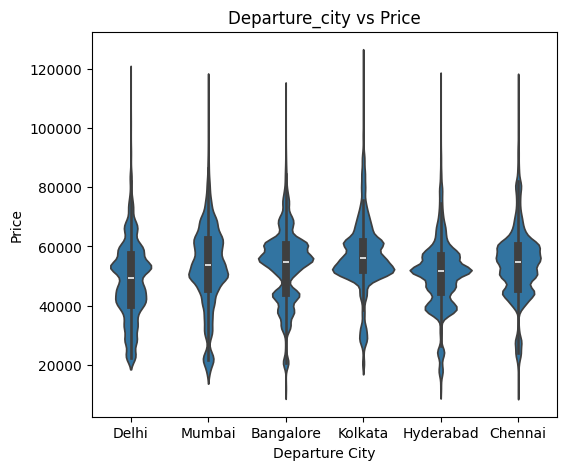

stop_count      0      1     2
from                          
Bangalore    6.47  93.01  0.53
Chennai      5.53  94.05  0.42
Delhi       15.49  82.14  2.37
Hyderabad    5.55  94.35  0.10
Kolkata      5.46  92.69  1.86
Mumbai      10.37  88.39  1.24


from
Mumbai       19858
Delhi        18316
Bangalore    16441
Kolkata      13473
Hyderabad    12870
Chennai      12529
Name: count, dtype: int64

In [17]:
print(df.groupby('from')['price'].describe())

plt.figure(figsize=(6,5))
sns.violinplot(data = df, x= 'from', y='price')
plt.xlabel('Departure City')
plt.ylabel('Price')
plt.title('Departure_city vs Price')
plt.show()

stop_proportion = (
    df.groupby('from')['stop_count']
    .value_counts(normalize=True)
    .unstack()
    .round(4) * 100
)
print(stop_proportion)
df['from'].value_counts()

**The same pattern found for departure city holds for destination city. Kolkata again shows the highest overall median price (₹55,377) despite not leading any individual stop-count segment, while Delhi again shows the lowest overall median (₹49,416) despite having competitive prices within each segment. The explanation is the same in both directions: Delhi consistently has the highest share of non-stop flights (16.94% as destination, 15.49% as origin), pulling its aggregate median down with cheap direct-flight prices, while Kolkata consistently has one of the lowest non-stop shares (4.84% as destination, 5.46% as origin), leaving its aggregate median dominated by pricier connecting-flight fares.**

             count          mean           std      min      25%      50%  \
to                                                                          
Bangalore  16198.0  53832.537597  12437.345377  12000.0  44144.0  54777.0   
Chennai    13158.0  53617.092871  11293.040689  12136.0  45672.0  55087.0   
Delhi      16707.0  48088.076914  12997.635643  22140.0  39555.0  49416.0   
Hyderabad  13675.0  50428.510128  11826.886627  12000.0  44462.0  51697.0   
Kolkata    14758.0  56738.007047  11683.037711  20000.0  51707.0  55377.0   
Mumbai     18991.0  52866.332842  14685.598232  17738.0  45883.0  53164.0   

               75%       max  
to                            
Bangalore  60978.0  114523.0  
Chennai    60396.0  111964.0  
Delhi      57081.0  123071.0  
Hyderabad  56588.0  114705.0  
Kolkata    62188.0  117307.0  
Mumbai     61985.0  115211.0  


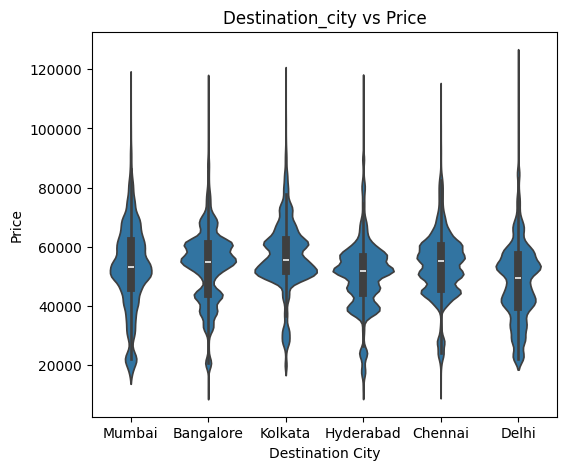

stop_count      0      1     2
to                            
Bangalore    6.62  93.20  0.19
Chennai      5.30  90.71  3.98
Delhi       16.94  82.83  0.23
Hyderabad    5.32  94.33  0.35
Kolkata      4.84  93.18  1.98
Mumbai      10.84  88.37  0.80


to
Mumbai       18991
Delhi        16707
Bangalore    16198
Kolkata      14758
Hyderabad    13675
Chennai      13158
Name: count, dtype: int64

In [18]:
print(df.groupby('to')['price'].describe())

plt.figure(figsize=(6,5))
sns.violinplot(data = df, x= 'to', y='price')
plt.xlabel('Destination City')
plt.ylabel('Price')
plt.title('Destination_city vs Price')
plt.show()

stop_proportion = (
    df.groupby('to')['stop_count']
    .value_counts(normalize=True)
    .unstack()
    .round(4) * 100
)
print(stop_proportion)
df['to'].value_counts()

## Route vs Price 
**Kolkata-Bangalore route is the costliest and Mumbai-Delhi is cheapest and the reason behind kolkata is that it is the costliest departure city due to uneven distribution of flights in stop_counts**

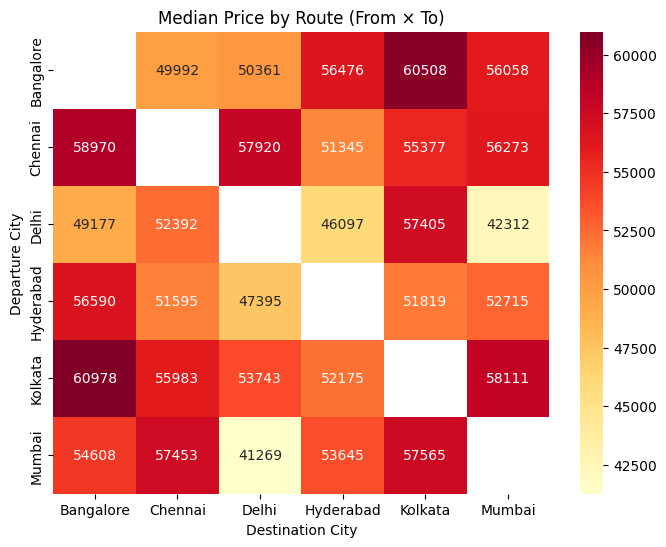

In [19]:
pivot = df.pivot_table(index='from', columns='to', values='price', aggfunc='median')
plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd')
plt.xlabel('Destination City')
plt.ylabel('Departure City')
plt.title('Median Price by Route (From × To)')
plt.show()

## Stop Count
**The variation of price with stop count is kind of linear. More stop counts shows high priced flights. But the costliest flight has1-stop.**

              count          mean           std      min      25%      50%  \
stop_count                                                                   
0            8102.0  27846.339052   6780.408368  12000.0  22152.0  27864.0   
1           84302.0  54687.377156  10622.569936  20000.0  48289.0  54608.0   
2            1083.0  70127.660203  12739.907274  12000.0  64387.0  68743.0   

                75%       max  
stop_count                     
0           32859.0   59573.0  
1           60508.0  123071.0  
2           76684.0  117307.0  


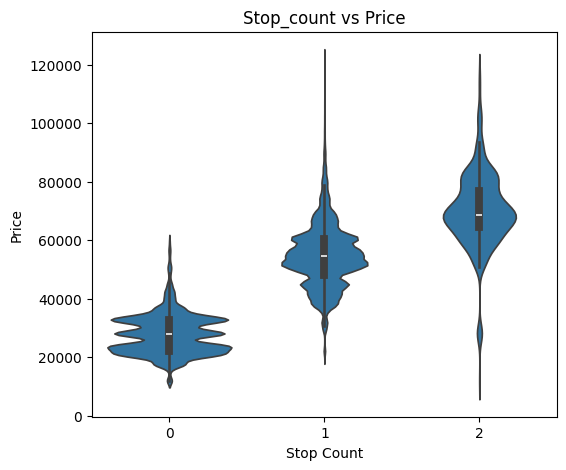

,date,airline,ch_code,flight_number,from,to,via_city,route,stop_count,arr_hour,arr_period,dep_hour,dep_period,duration_mins,days_left,price
54711,2022-02-13,Vistara,UK,772,Kolkata,Delhi,NaN,Kolkata-Delhi,1,23,Night,10,Morning,810,3,123071


In [20]:
print(df.groupby('stop_count')['price'].describe())

plt.figure(figsize=(6,5))
sns.violinplot(data = df, x= 'stop_count', y='price')
plt.xlabel('Stop Count')
plt.ylabel('Price')
plt.title('Stop_count vs Price')
plt.show()

df[df['price'] == df['price'].max()]

## Arrival_Period vs Price
**Evening arrival time is highest priced while Afternoon arrival period is the cheapest. Unlike the City and route level findings, stop count barely varies among the arrival periods, it does not explain the reason behind why evening is most costly arrival period.**

**Also the sample is Late Night is small only 1994 flights data**

              count          mean           std      min      25%      50%  \
arr_period                                                                   
Afternoon   15787.0  50642.894787  12653.168588  12000.0  41652.0  51817.0   
Evening     20817.0  54115.909833  11947.977456  20606.0  48213.0  54777.0   
Late_Night   1994.0  51490.450853  10328.981858  22140.0  45600.0  54608.0   
Morning     25137.0  51392.128018  13396.331687  12000.0  43865.0  52063.0   
Night       29752.0  53484.418123  13387.009576  15000.0  45883.0  53937.0   

                75%       max  
arr_period                     
Afternoon   58282.0  117307.0  
Evening     60508.0  114705.0  
Late_Night  57920.0   89257.0  
Morning     60260.0  111964.0  
Night       60555.0  123071.0  


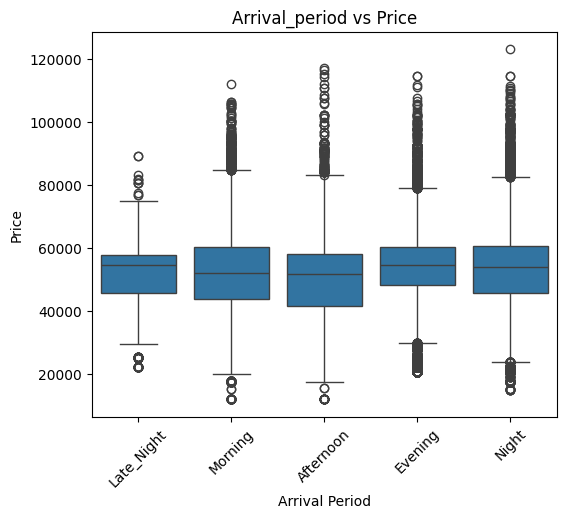

arr_period
Afternoon     0.915373
Evening       0.956430
Late_Night    0.915747
Morning       0.910888
Night         0.920409
Name: stop_count, dtype: float64

In [21]:
print(df.groupby('arr_period')['price'].describe())

order = ['Late_Night','Morning','Afternoon','Evening','Night']

plt.figure(figsize=(6,5))
sns.boxplot(data=df, x='arr_period', y='price', order=order)
plt.xlabel('Arrival Period')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.title('Arrival_period vs Price')
plt.show()

df.groupby('arr_period')['stop_count'].mean()

## Departure_period vs Price
**Like Arrival period, same trend can be seen here too that Evening departure time is highest priced but here, Late Night departure period is the cheapest but since Late Night has only 1517 samples it can be considered as a good storyteller so still Afternoon is the cheapest departure period.**

              count          mean           std      min      25%      50%  \
dep_period                                                                   
Afternoon   15033.0  50428.471895  12536.755740  12000.0  43729.0  51707.0   
Evening     18237.0  53551.071613  13836.928925  15000.0  44280.0  54608.0   
Late_Night   1517.0  50379.563612  14907.479989  12000.0  40369.0  50957.0   
Morning     40894.0  53058.582530  12875.285237  12000.0  45805.0  53645.0   
Night       17806.0  52280.634674  12199.260038  15000.0  45672.0  53164.0   

                75%       max  
dep_period                     
Afternoon   57920.0  111437.0  
Evening     61583.0  116562.0  
Late_Night  57992.0  117307.0  
Morning     60396.0  123071.0  
Night       60160.0  115211.0  


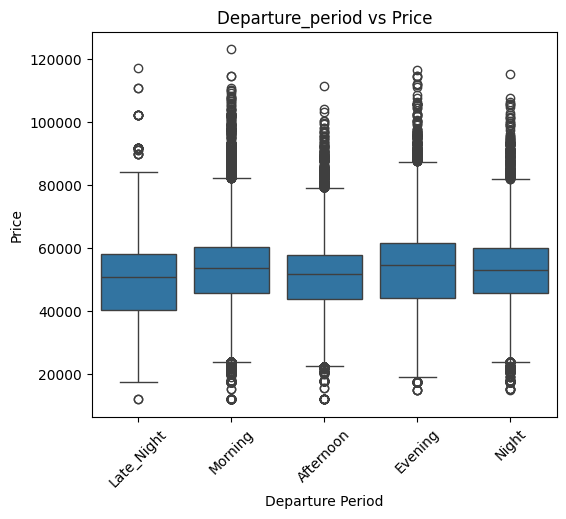

dep_period
Afternoon     0.933746
Evening       0.912321
Late_Night    0.957811
Morning       0.928987
Night         0.918230
Name: stop_count, dtype: float64

In [22]:
print(df.groupby('dep_period')['price'].describe())

order = ['Late_Night','Morning','Afternoon','Evening','Night']

plt.figure(figsize=(6,5))
sns.boxplot(data=df, x='dep_period', y='price', order=order)
plt.xlabel('Departure Period')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.title('Departure_period vs Price')
plt.show()

df.groupby('dep_period')['stop_count'].mean()

## `Duration_mins` vs `Price`
**Scatter plot does not really show well relationship between `duration_mins` vs `price` so for cross checking I plotted `Duration` vs `Median Price` lline plot also which shows price jumps sharply once duration goes above ~200 minutes (non-stop → has-a-stop), then stays roughly flat around ₹52,000–55,500 all the way from 200 to 1600 minutes. It does not keep rising as duration increases. After 1800 the median prices are not trustworthy since lack of number of samples, they are more like actual prices**

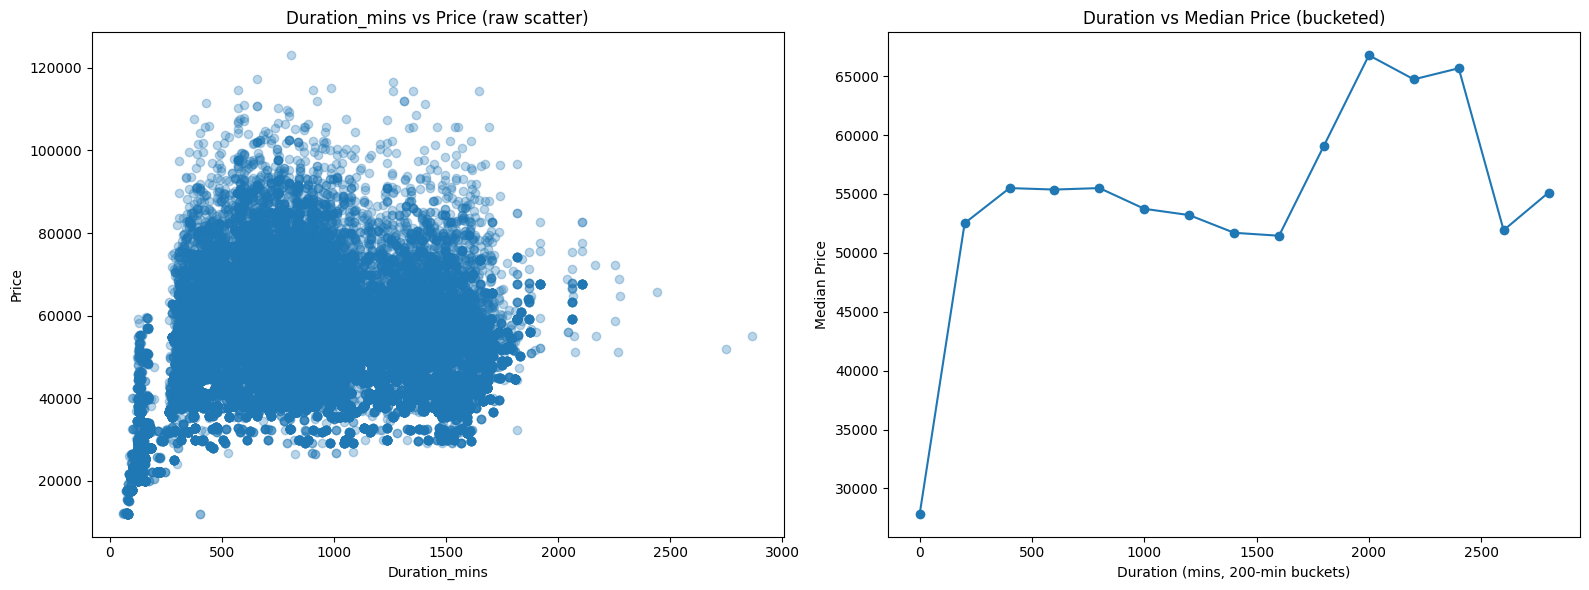

duration_bucket
0        8109
200      6563
400     13538
600     19885
800     18008
1000     8046
1200     8058
1400     8349
1600     2645
1800      223
2000       55
2200        5
2400        1
2600        1
2800        1
Name: price, dtype: int64
duration_bucket
0        8109
200      6563
400     13538
600     19885
800     18008
1000     8046
1200     8058
1400     8349
1600     2645
1800      223
2000       55
2200        5
2400        1
2600        1
2800        1
Name: price, dtype: int64


In [23]:
df['duration_bucket'] = (df['duration_mins'] // 200) * 200
bucket_median = df.groupby('duration_bucket')['price'].median()
bucket_count = df.groupby('duration_bucket')['price'].count()

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ax[0].scatter(df['duration_mins'], df['price'], alpha=0.3)
ax[0].set_xlabel('Duration_mins')
ax[0].set_ylabel('Price')
ax[0].set_title('Duration_mins vs Price (raw scatter)')

bucket_median.plot(ax=ax[1], marker='o')
ax[1].set_xlabel('Duration (mins, 200-min buckets)')
ax[1].set_ylabel('Median Price')
ax[1].set_title('Duration vs Median Price (bucketed)')

plt.tight_layout()
plt.show()

print(bucket_count)
print(bucket_count)

## Days_left vs Price
**When a scatterplot is plotted between days_left and price, it shows almost no visible correlation — points are spread across the full price range at every value of days_left, and the Pearson/Spearman correlation coefficients confirm this numerically (-0.09 and -0.08, both near zero)**

**However, when the median price grouped by days_left is plotted as a line, a clear relationship emerges can be seen that price stays flat (~₹52,000–54,000) for more than 10_days left for bookings, days before departure, but it rises sharply in the final few days, reaching ~₹65,000+ at days_left = 1.**

Pearson corr: -0.09128941558253932
Spearman corr: -0.07567778874455726


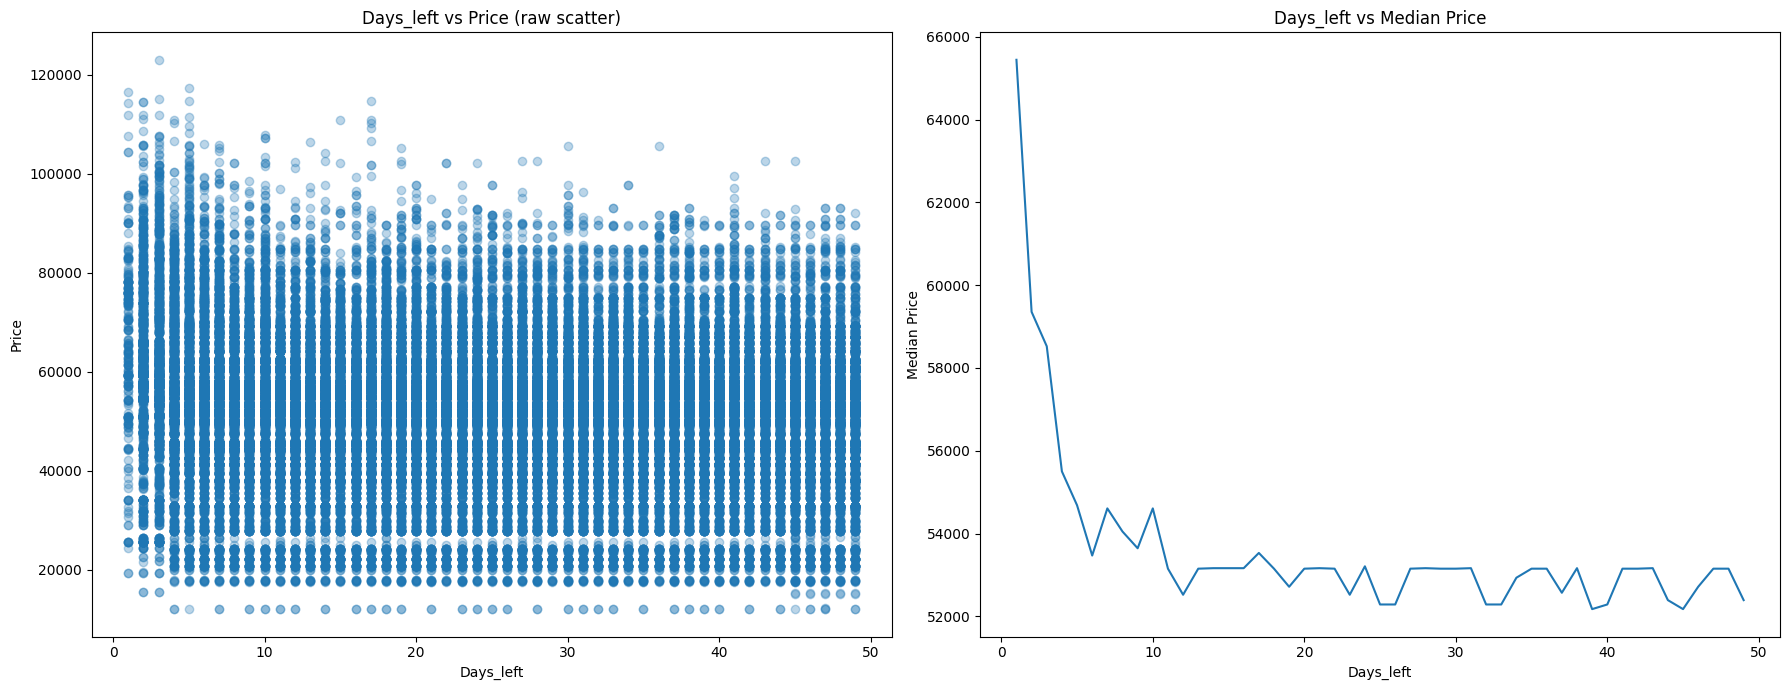

In [24]:
print('Pearson corr:' ,df['price'].corr(df['days_left']))
print('Spearman corr:' ,df['price'].corr(df['days_left'], method= 'spearman'))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# left plot: scatter
axes[0].scatter(df['days_left'], df['price'], alpha=0.3)
axes[0].set_xlabel('Days_left')
axes[0].set_ylabel('Price')
axes[0].set_title('Days_left vs Price (raw scatter)')

# right plot: median line
df.groupby('days_left')['price'].median().plot(ax=axes[1])
axes[1].set_xlabel('Days_left')
axes[1].set_ylabel('Median Price')
axes[1].set_title('Days_left vs Median Price')

plt.tight_layout()
plt.show()

## Airline vs Stop_count
**Air India and Vistara have a similar stop_count distribution overall — both around 89-90% 1-stop flights. The only notable difference: Vistara has a slightly higher share of 2-stop flights (1.43% vs 0.67%) and slightly lower non-stop share (8.27% vs 9.39%) compared to Air India.**

In [25]:
(df.groupby('airline')['stop_count'].value_counts(normalize=True)*100).unstack()

stop_count,0,1,2
airline,,,
Air India,9.389629,89.944677,0.665694
Vistara,8.273779,90.300220,1.426001


## Airline vs Route
**26/30 routes are more expensive in `Vistara` than `Air India`**

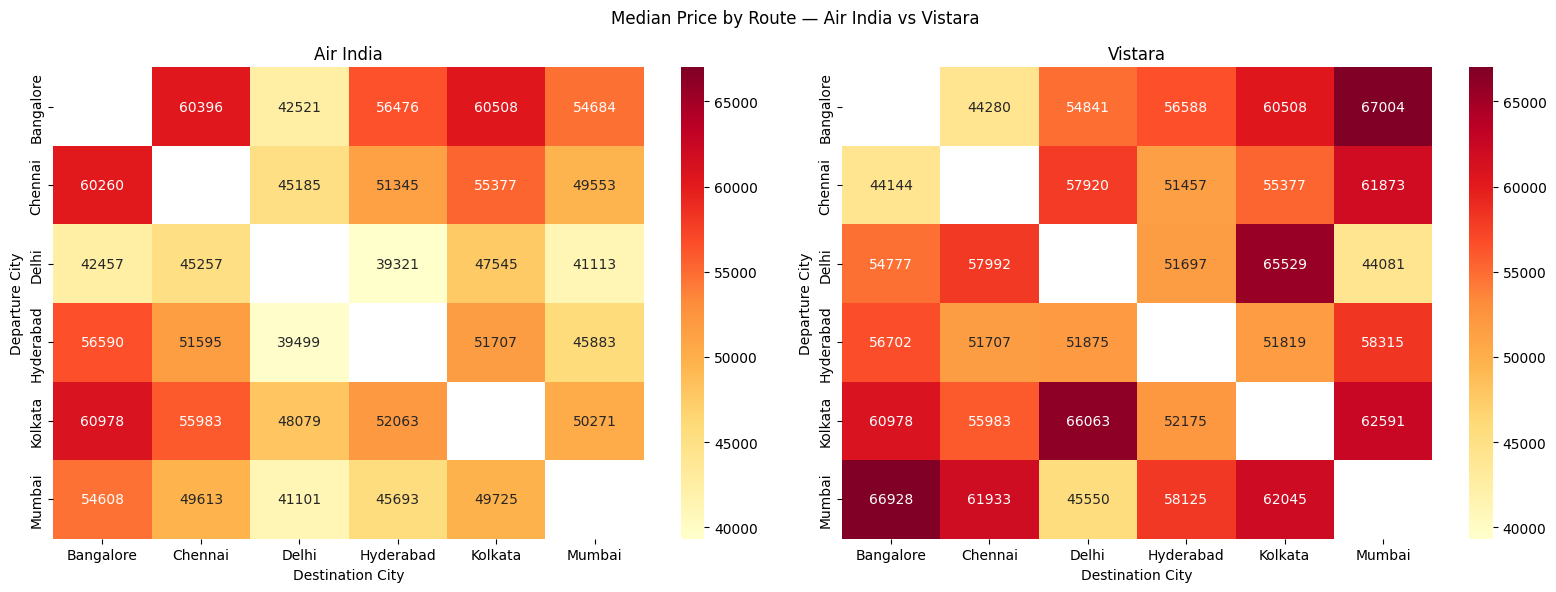

In [26]:
vmin = df['price'].groupby([df['airline'], df['from'], df['to']]).median().min()
vmax = df['price'].groupby([df['airline'], df['from'], df['to']]).median().max()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, airline in enumerate(df['airline'].unique()):
    sub = df[df['airline'] == airline]
    pivot = sub.pivot_table(index='from', columns='to', values='price', aggfunc='median')
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', vmin=vmin, vmax=vmax, ax=axes[i])
    axes[i].set_xlabel('Destination City')
    axes[i].set_ylabel('Departure City')
    axes[i].set_title(airline)

plt.suptitle('Median Price by Route — Air India vs Vistara')
plt.tight_layout()
plt.show()

In [27]:
df['day_of_week'] = df['date'].dt.day_name()
df['is_weekend'] = np.where(df['day_of_week'].isin(['Sunday','Saturday']), 1, 0)

In [28]:
order = ['date', 'day_of_week', 'is_weekend', 'airline', 'ch_code', 'flight_number', 'from', 'to', 'via_city',
       'route', 'stop_count', 'arr_hour', 'arr_period', 'dep_hour',
       'dep_period', 'duration_mins', 'days_left', 'price', 'duration_bucket'
        ]

df = df[order]
df.sample(3)

,date,day_of_week,is_weekend,airline,ch_code,flight_number,from,to,via_city,route,stop_count,arr_hour,arr_period,dep_hour,dep_period,duration_mins,days_left,price,duration_bucket
89290,2022-02-12,Saturday,1,Vistara,UK,832,Chennai,Kolkata,NaN,Chennai-Kolkata,1,9,Morning,6,Morning,1600,2,69489,1600
83861,2022-02-15,Tuesday,0,Vistara,UK,838,Chennai,Mumbai,NaN,Chennai-Mumbai,1,7,Morning,21,Night,650,5,61873,600
19624,2022-02-25,Friday,0,Air India,AI,809,Mumbai,Delhi,NaN,Mumbai-Delhi,0,12,Afternoon,10,Morning,135,15,22140,0


## Day_of_Week vs Price
**Median of price across all days are same no surprising finding everything is flat**

               count          mean           std      min      25%      50%  \
day_of_week                                                                   
Monday       13845.0  52136.734345  12724.043925  12000.0  44583.0  53152.0   
Tuesday      13687.0  52375.258274  13170.740548  12000.0  44583.0  53152.0   
Wednesday    13747.0  52281.394122  12814.836408  15000.0  44622.0  53152.0   
Thursday     13680.0  52165.448465  12597.509304  12000.0  45185.0  53164.0   
Friday       12100.0  52563.739917  12569.137615  17548.0  45257.0  53164.0   
Saturday     13202.0  52927.087335  13152.173831  12000.0  45257.0  53743.0   
Sunday       13226.0  53381.294193  13664.208413  12000.0  45257.0  53835.0   

                 75%       max  
day_of_week                     
Monday       60260.0  110936.0  
Tuesday      60365.0  117307.0  
Wednesday    60365.0  106416.0  
Thursday     60260.0  105744.0  
Friday       60396.0  116562.0  
Saturday     60410.0  114523.0  
Sunday       60601.0  12

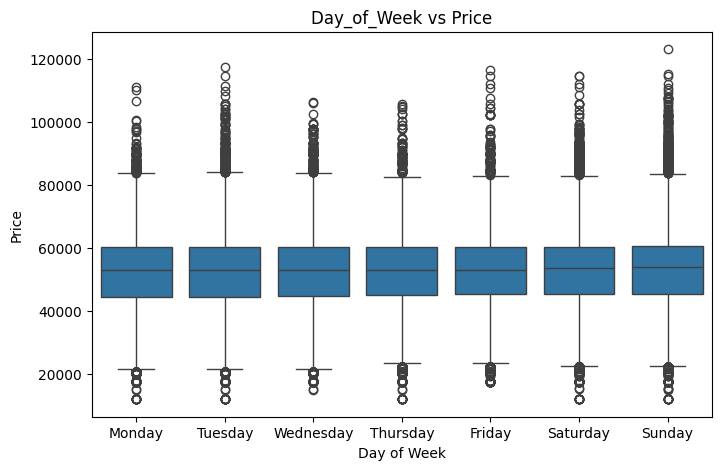

In [29]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
print(df.groupby('day_of_week')['price'].describe().reindex(day_order))

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='day_of_week', y='price', order=day_order)
plt.xlabel('Day of Week')
plt.ylabel('Price')
plt.title('Day_of_Week vs Price')
plt.show()

              count          mean           std      min      25%      50%  \
is_weekend                                                                   
0           67059.0  52297.978795  12782.416195  12000.0  45097.0  53164.0   
1           26428.0  53154.397003  13412.536728  12000.0  45257.0  53743.0   

                75%       max  
is_weekend                     
0           60351.0  117307.0  
1           60508.0  123071.0  


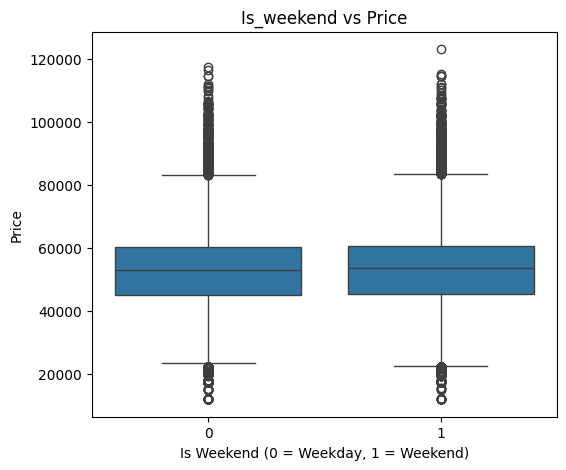

In [30]:
print(df.groupby('is_weekend')['price'].describe())

plt.figure(figsize=(6,5))
sns.boxplot(data=df, x='is_weekend', y='price')
plt.xlabel('Is Weekend (0 = Weekday, 1 = Weekend)')
plt.ylabel('Price')
plt.title('Is_weekend vs Price')
plt.show()

## Overall Summary — Business Class EDA

- **`stop_count` sabse bada price driver hai** — non-stop flights sasti hain (~₹27,860), 1-stop/2-stop kaafi mehenge (~₹54,600/₹70,100)
- **Kolkata/Delhi ka apparent city-level price difference asal mein ek mixing artifact nikla** — Delhi ka non-stop share sabse zyada hai isliye uska overall median sabse kam dikhta hai, Kolkata ka ulta. Har stop-count segment ke andar Bangalore hi actually costliest hai
- **`duration_mins` ka price ke saath sirf threshold-shaped relationship hai** — non-stop se has-a-stop tak jump hota hai, uske baad flat/thoda decline
- **`days_left` ka linear correlation near-zero hai lekin ek real last-minute price spike hai** — sirf departure se 1-5 din pehle price achanak badhta hai, baaki 45 din flat rehta hai
- **`Vistara` `Air India` se costlier hai** — na duration, na stop_count, na route-mix se explain hota; likely brand/service-tier premium
- **`day_of_week`/`is_weekend` ka koi meaningful effect nahi hai** — price flat rehta hai poore hafte mein